# 期货信号回测框架（IM 主力合约版）

本 notebook 实现一个基于仓位信号的期货回测框架，支持：
- 只使用 IM 主力合约
- 每日收盘无敞口，次日开盘恢复对锁底仓
- 初始资金 5000 万
- **回测框架不限制信号频率，需传入仓位信号数据运行回测**

## 1. 导入依赖

导入回测框架所需的 Python 库：
- `pandas`: 数据处理和分析
- `numpy`: 数值计算
- `typing`: 类型提示
- `matplotlib`: 绘图库

In [31]:
import pandas as pd
import numpy as np
from typing import Dict, Optional, Tuple, List
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# 设置绘图样式
sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 2. 数据加载与主力合约筛选

**回测逻辑说明：**
1. 加载 1 分钟期货行情数据（包含 TWAP 价格）
2. 筛选 IM（中证 1000 股指期货）合约数据
3. 每日选择 Code 最大的合约作为主力合约
4. 主力合约用于确定当日的交易标的

In [32]:
# 加载行情数据
price_data = pd.read_parquet('/home/dev1/future_min1/20200102_20250313_bar.parquet')[['twap']].reset_index()
print("行情数据形状:", price_data.shape)

# 筛选 IM 合约
im_data = price_data[price_data['Code'].str.startswith('IM')].copy()
print("IM 合约数据形状:", im_data.shape)
print("IM 合约日期范围:", im_data['date'].min(), "-", im_data['date'].max())

行情数据形状: (1057822, 4)
IM 合约数据形状: (153358, 4)
IM 合约日期范围: 20220722 - 20250313


In [33]:
# 筛选每日 IM 主力合约（Code 最大的合约）
def select_main_contract(df):
    """筛选每日主力合约（Code 最大值）"""
    return df.groupby('date', group_keys=False).apply(
        lambda x: x[x['Code'] == x['Code'].max()]
    ).reset_index(drop=True)

main_contract_data = select_main_contract(im_data)
print("主力合约数据形状:", main_contract_data.shape)
print("交易日数量:", main_contract_data['date'].nunique())
print("主力合约示例:")
main_contract_data.head(10)

主力合约数据形状: (153358, 4)
交易日数量: 639
主力合约示例:


,date,minTime,Code,twap
0,20220722,093100,IM2208,7052.306087
1,20220722,093200,IM2208,7066.660000
2,20220722,093300,IM2208,7080.682759
3,20220722,093400,IM2208,7074.083810
4,20220722,093500,IM2208,7072.356250
5,20220722,093600,IM2208,7076.723478
6,20220722,093700,IM2208,7073.693182
7,20220722,093800,IM2208,7068.310870
8,20220722,093900,IM2208,7071.979775
9,20220722,094000,IM2208,7076.816667


## 3. 回测引擎类定义

### PositionBacktester 类核心逻辑

**初始化参数：**
- `price_data`: 行情数据（包含 date, minTime, Code, twap 列）
- `slippage`: 滑点（指数点），默认 0.2
- `initial_capital`: 初始资金，默认 5000 万
- `base_position`: 对锁底仓手数，默认 10 手

**核心方法：**
1. `_prepare_data()`: 预处理数据，构建快速查找索引
2. `_get_next_twap()`: 获取下一分钟 TWAP（成交价格）
3. `_get_open_twap()`: 获取开盘 TWAP
4. `_get_close_twap()`: 获取收盘 TWAP
5. `_calculate_pnl()`: 计算单笔交易盈亏
6. `_apply_slippage()`: 应用滑点到成交价格
7. `run_backtest()`: 执行回测（核心方法）
8. `calculate_performance_metrics()`: 计算绩效指标
9. `plot_performance()`: 绘制日度绩效分析图表

**回测流程（run_backtest）：**
```
遍历每个交易日:
    1. 开盘建立对锁底仓（base_position 手多 + 空）
    2. 处理传入的仓位信号:
       - direction=1: 多头信号，平空仓（买入）
       - direction=-1: 空头信号，平多仓（卖出）
       - 成交价格 = 下一分钟 TWAP ± 滑点
       - PnL = (收盘价 - 成交价) × 手数 × 乘数 (多头)
       - PnL = (成交价 - 收盘价) × 手数 × 乘数 (空头)
    3. 收盘强制平仓:
       - 计算当日净敞口 = 多头手数 - 空头手数
       - 以收盘价平仓所有敞口
    4. 记录日度统计:
       - 累计 PnL
       - 净值 (NAV)
```

**绩效指标：**
- 胜率 = 盈利天数 / 总天数
- 最大回撤 = max((历史最高净值 - 当前净值) / 历史最高净值)
- 夏普比率 = √252 × 日均收益 / 收益标准差

In [34]:
class PositionBacktester:
    """
    期货仓位信号回测引擎（IM 主力合约版）
    
    特性:
    - 只使用 IM 主力合约
    - 每日收盘无敞口，次日开盘恢复对锁底仓
    - 初始资金 5000 万
    - **回测框架不限制信号频率，需传入仓位信号数据**
    
    参数:
    - price_data: pd.DataFrame, 行情数据，包含 columns: ['date', 'minTime', 'Code', 'twap']
    - slippage: float, 滑点（指数点），默认 0.2
    - initial_capital: float, 初始资金，默认 5000 万
    - base_position: int, 对锁底仓手数，默认 10 手
    
    信号格式:
    - position_df: pd.DataFrame, 包含 columns: ['date', 'minTime', 'Code', 'direction', 'numbers']
    - direction: 1 表示多头信号（平空），-1 表示空头信号（平多）
    - numbers: 手数（正整数）
    """
    
    # IM 合约乘数
    IM_MULTIPLIER = 200
    
    def __init__(self, 
                 price_data: pd.DataFrame,
                 slippage: float = 0.2,
                 initial_capital: float = 5e7,
                 base_position: int = 10):
        
        self.price_data = price_data.copy()
        self.slippage = slippage
        self.initial_capital = initial_capital
        self.base_position = base_position  # 对锁底仓手数
        
        # 合约乘数
        self.contract_multiplier = self.IM_MULTIPLIER
        
        # 预处理数据：构建查找索引
        self._prepare_data()
        
        # 回测结果
        self.trade_records = None
        self.daily_stats = None
    
    def _prepare_data(self):
        """预处理行情数据，构建快速查找索引"""
        # 确保数据类型正确
        self.price_data['date'] = self.price_data['date']
        self.price_data['minTime'] = self.price_data['minTime']
        
        # 按 date, Code, minTime 排序
        self.price_data = self.price_data.sort_values(['date', 'Code', 'minTime']).reset_index(drop=True)
        
        # 构建 (date, Code) -> minTime 列表的映射
        self.time_index = {}
        for (date, code), group in self.price_data.groupby(['date', 'Code']):
            times = sorted(group['minTime'].unique())
            self.time_index[(date, code)] = times
        
        # 构建快速查找表：(date, Code, minTime) -> twap
        self.price_lookup = {}
        for _, row in self.price_data.iterrows():
            key = (row['date'], row['Code'], row['minTime'])
            self.price_lookup[key] = row['twap']
        
        # 获取每个交易日的交易时间范围
        self.daily_times = {}
        for (date, code), group in self.price_data.groupby(['date', 'Code']):
            times = sorted(group['minTime'].unique())
            if (date, code) not in self.daily_times:
                self.daily_times[(date, code)] = (times[0], times[-1])
        
        # 获取所有交易日列表
        self.trading_dates = sorted(self.price_data['date'].unique())
    
    def _get_next_twap(self, date: str, code: str, min_time: str) -> Optional[float]:
        """
        获取下一个分钟的 TWAP 价格（成交价格）
        如果当前是当日最后一个时间，返回 None（无法成交）
        """
        if (date, code) not in self.time_index:
            return None
        
        times = self.time_index[(date, code)]
        try:
            current_idx = times.index(min_time)
            if current_idx >= len(times) - 1:
                # 当前是当日最后一个时间，无法在下一个分钟成交
                return None
            next_time = times[current_idx + 1]
            return self.price_lookup.get((date, code, next_time))
        except ValueError:
            return None
    
    def _get_close_twap(self, date: int, code: str) -> Optional[float]:
        """获取当日最后一个分钟的 TWAP 作为收盘价"""
        if (date, code) not in self.daily_times:
            return None
        _, last_time = self.daily_times[(date, code)]
        return self.price_lookup.get((date, code, last_time))
    
    def _get_open_twap(self, date: int, code: str) -> Optional[float]:
        """获取当日第一个分钟的 TWAP 作为开盘价"""
        if (date, code) not in self.daily_times:
            return None
        first_time, _ = self.daily_times[(date, code)]
        return self.price_lookup.get((date, code, first_time))
    
    def _calculate_pnl(self, 
                       direction: int, 
                       exec_price: float, 
                       close_price: float, 
                       numbers: int, 
                       multiplier: float) -> float:
        """
        计算单笔交易 PnL
        
        参数:
        - direction: 1 表示多头信号（平空仓），-1 表示空头信号（平多仓）
        - exec_price: 成交价格（已考虑滑点）
        - close_price: 当日收盘 TWAP
        - numbers: 手数
        - multiplier: 合约乘数
        
        返回:
        - PnL
        
        公式:
        - 买入平仓（平空，direction=1）: PnL = (收盘价 - 成交价) × 手数 × 乘数
        - 卖出平仓（平多，direction=-1）: PnL = (成交价 - 收盘价) × 手数 × 乘数
        """
        if direction == 1:  # 多头信号，平空仓（买入平仓）
            pnl = (close_price - exec_price) * numbers * multiplier
        else:  # direction == -1, 空头信号，平多仓（卖出平仓）
            pnl = (exec_price - close_price) * numbers * multiplier
        return pnl
    
    def _apply_slippage(self, price: float, direction: int) -> float:
        """
        应用滑点到成交价格
        
        - 买入（direction=1）: 成交价 = 理论价 + 滑点
        - 卖出（direction=-1）: 成交价 = 理论价 - 滑点
        """
        if direction == 1:  # 买入
            return price + self.slippage
        else:  # 卖出
            return price - self.slippage
    
    def _get_main_contract(self, date: int) -> Optional[str]:
        """获取指定日期的主力合约代码"""
        day_data = self.price_data[self.price_data['date'] == date]
        if len(day_data) == 0:
            return None
        return day_data['Code'].max()
    
    def run_backtest(self, position_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        执行回测
        
        参数:
        - position_df: pd.DataFrame, 仓位信号（必需）
          columns: ['date', 'minTime', 'Code', 'direction', 'numbers']
        
        返回:
        - (trade_records, daily_stats): 交易记录和日度统计
        """
        # 确保 position_df 的 date 列是整数类型
        position_df = position_df.copy()
        
        # 交易记录
        all_trade_records = []
        
        # 日度统计
        all_daily_stats = []
        
        # 累计 PnL
        cumulative_pnl = 0.0
        
        # 遍历每个交易日
        for date in self.trading_dates:
            # 获取当日主力合约
            code = self._get_main_contract(date)
            if code is None:
                continue
            
            # 获取当日所有时间
            if (date, code) not in self.time_index:
                continue
            
            times = self.time_index[(date, code)]
            first_time = times[0]
            last_time = times[-1]
            
            # 获取开盘价和收盘价
            open_price = self._get_open_twap(date, code)
            close_price = self._get_close_twap(date, code)
            
            if open_price is None or close_price is None:
                continue
            
            # === 1. 开盘建立对锁底仓 ===
            # 在开盘时建立 base_position 手对锁底仓
            # 多头底仓：以开盘价买入 base_position 手
            # 空头底仓：以开盘价卖出 base_position 手
            # 对锁仓本身不产生 PnL，只是作为底仓
            base_position_record = {
                'date': date,
                'minTime': first_time,
                'Code': code,
                'direction': 0,  # 0 表示建立对锁底仓
                'numbers': self.base_position,
                'theoretical_price': open_price,
                'exec_price': open_price,
                'close_price': close_price,
                'multiplier': self.contract_multiplier,
                'pnl': 0.0,  # 对锁仓不产生 PnL
                'signal_type': 'base_position'
            }
            all_trade_records.append(base_position_record)
            
            # === 2. 处理交易信号 ===
            # 使用传入的信号
            day_signals = position_df[position_df['date'] == date]
            
            # 当日交易统计
            daily_long_trades = 0  # 多头交易手数
            daily_short_trades = 0  # 空头交易手数
            daily_pnl = 0.0
            
            # 处理每个信号
            if len(day_signals) > 0:
                for _, signal in day_signals.iterrows():
                    min_time = signal['minTime']
                    direction = signal['direction']
                    numbers = signal['numbers']
                    
                    # 获取下一个分钟的 TWAP 作为理论成交价
                    theoretical_price = self._get_next_twap(date, code, min_time)
                    
                    if theoretical_price is None:
                        # 无法成交（当日最后一个信号）
                        continue
                    
                    # 应用滑点
                    exec_price = self._apply_slippage(theoretical_price, direction)
                    
                    # 计算 PnL
                    pnl = self._calculate_pnl(direction, exec_price, close_price, numbers, self.contract_multiplier)
                    
                    # 记录交易
                    trade_record = {
                        'date': date,
                        'minTime': min_time,
                        'Code': code,
                        'direction': direction,
                        'numbers': numbers,
                        'theoretical_price': theoretical_price,
                        'exec_price': exec_price,
                        'close_price': close_price,
                        'multiplier': self.contract_multiplier,
                        'pnl': pnl,
                        'signal_type': 'regular'
                    }
                    all_trade_records.append(trade_record)
                    
                    # 统计
                    if direction == 1:
                        daily_long_trades += numbers
                    else:
                        daily_short_trades += numbers
                    daily_pnl += pnl
            
            # === 3. 收盘强制平仓 ===
            # 计算当日净敞口
            net_exposure = daily_long_trades - daily_short_trades
            
            # 如果有敞口，需要平仓
            close_pnl = 0.0
            if net_exposure != 0:
                # 净敞口 > 0: 多头过多，需要卖出平仓
                # 净敞口 < 0: 空头过多，需要买入平仓
                close_direction = -1 if net_exposure > 0 else 1
                close_numbers = abs(net_exposure)
                
                # 以收盘价平仓
                close_pnl = self._calculate_pnl(close_direction, close_price, close_price, close_numbers, self.contract_multiplier)
                
                close_record = {
                    'date': date,
                    'minTime': last_time,
                    'Code': code,
                    'direction': close_direction,
                    'numbers': close_numbers,
                    'theoretical_price': close_price,
                    'exec_price': close_price,
                    'close_price': close_price,
                    'multiplier': self.contract_multiplier,
                    'pnl': close_pnl,
                    'signal_type': 'close_position'
                }
                all_trade_records.append(close_record)
                daily_pnl += close_pnl
            
            # 更新累计 PnL
            cumulative_pnl += daily_pnl
            
            # 计算净值
            nav = (self.initial_capital + cumulative_pnl) / self.initial_capital
            
            # 日度统计
            all_daily_stats.append({
                'date': date,
                'code': code,
                'long_trades': daily_long_trades,
                'short_trades': daily_short_trades,
                'net_exposure': net_exposure,
                'daily_pnl': daily_pnl,
                'cumulative_pnl': cumulative_pnl,
                'nav': nav,
                'open_price': open_price,
                'close_price': close_price
            })
        
        # 转换为 DataFrame
        self.trade_records = pd.DataFrame(all_trade_records)
        self.daily_stats = pd.DataFrame(all_daily_stats)
        
        return self.trade_records, self.daily_stats
    
    def calculate_performance_metrics(self) -> dict:
        """计算绩效指标"""
        if self.daily_stats is None or len(self.daily_stats) == 0:
            return {}
        
        df = self.daily_stats
        
        total_days = len(df)
        win_days = (df['daily_pnl'] > 0).sum()
        lose_days = (df['daily_pnl'] < 0).sum()
        win_rate = win_days / total_days * 100
        
        total_pnl = df['cumulative_pnl'].iloc[-1]
        final_nav = df['nav'].iloc[-1]
        
        # 计算最大回撤
        df['cum_nav'] = df['nav'].cummax()
        df['drawdown'] = (df['cum_nav'] - df['nav']) / df['cum_nav'] * 100
        max_drawdown = df['drawdown'].max()
        
        # 计算夏普比率（假设无风险利率为 0）
        daily_returns = df['daily_pnl'] / self.initial_capital
        sharpe_ratio = np.sqrt(252) * daily_returns.mean() / daily_returns.std() if daily_returns.std() > 0 else 0
        
        return {
            'total_days': total_days,
            'win_days': win_days,
            'lose_days': lose_days,
            'win_rate': win_rate,
            'total_pnl': total_pnl,
            'final_nav': final_nav,
            'max_drawdown': max_drawdown,
            'sharpe_ratio': sharpe_ratio
        }
    
    def plot_performance(self, title: str = '回测绩效分析', figsize: tuple = (14, 10)):
        """
        绘制日度绩效分析图表
        
        参数:
        - title: str, 图表标题
        - figsize: tuple, 图表尺寸 (宽，高)
        
        返回:
        - fig, axes: matplotlib 图形和轴对象
        """
        if self.daily_stats is None or len(self.daily_stats) == 0:
            print("请先运行回测：backtester.run_backtest(position_df)")
            return None
        
        df = self.daily_stats.copy()
        
        # 计算回撤（如果尚未计算）
        if 'drawdown' not in df.columns:
            df['cum_nav'] = df['nav'].cummax()
            df['drawdown'] = (df['cum_nav'] - df['nav']) / df['cum_nav'] * 100
        
        # 创建 2x2 子图
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle(title, fontsize=16, fontweight='bold')
        
        # === 图 1：净值曲线 (NAV) ===
        ax1 = axes[0, 0]
        ax1.plot(df['date'], df['nav'], linewidth=1.5, color='#2E86AB')
        ax1.axhline(y=1.0, linestyle='--', color='gray', alpha=0.5, label='Initial NAV')
        ax1.fill_between(df['date'], df['nav'], 1.0, 
                        where=(df['nav'] >= 1.0), interpolate=True, alpha=0.3, color='red', label='Profit')
        ax1.fill_between(df['date'], df['nav'], 1.0, 
                        where=(df['nav'] < 1.0), interpolate=True, alpha=0.3, color='green', label='Loss')
        ax1.set_title('Net Asset Value (NAV)', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Trading Date')
        ax1.set_ylabel('NAV')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        # Annotate final NAV
        final_nav = df['nav'].iloc[-1]
        ax1.annotate(f'Final NAV: {final_nav:.4f}', 
                    xy=(df['date'].iloc[-1], final_nav),
                    xytext=(0.02, 0.98), textcoords='axes fraction',
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # === 图 2：累计 PnL 曲线 ===
        ax2 = axes[0, 1]
        ax2.plot(df['date'], df['cumulative_pnl'], linewidth=1.5, color='#A23B72')
        ax2.axhline(y=0, linestyle='-', color='black', linewidth=0.5, alpha=0.5)
        ax2.fill_between(df['date'], df['cumulative_pnl'], 0, 
                        where=(df['cumulative_pnl'] >= 0), interpolate=True, alpha=0.3, color='red')
        ax2.fill_between(df['date'], df['cumulative_pnl'], 0, 
                        where=(df['cumulative_pnl'] < 0), interpolate=True, alpha=0.3, color='green')
        ax2.set_title('Cumulative PnL', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Trading Date')
        ax2.set_ylabel('Cumulative PnL')
        ax2.grid(True, alpha=0.3)
        
        # Annotate final cumulative PnL
        final_pnl = df['cumulative_pnl'].iloc[-1]
        ax2.annotate(f'Cumulative PnL: {final_pnl:,.0f}', 
                    xy=(df['date'].iloc[-1], final_pnl),
                    xytext=(0.02, 0.98), textcoords='axes fraction',
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # === 图 3：回撤曲线 (Drawdown) ===
        ax3 = axes[1, 0]
        ax3.fill_between(df['date'], df['drawdown'], 0, color='#F18F01', alpha=0.5, label='Drawdown')
        ax3.set_title('Drawdown', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Trading Date')
        ax3.set_ylabel('Drawdown (%)')
        ax3.legend(loc='upper left')
        ax3.grid(True, alpha=0.3)
        
        # Annotate maximum drawdown
        max_dd_idx = df['drawdown'].idxmax()
        max_dd = df['drawdown'].max()
        max_dd_date = df.loc[max_dd_idx, 'date']
        ax3.annotate(f'Max Drawdown: {max_dd:.2f}%\nDate: {max_dd_date}', 
                    xy=(max_dd_date, max_dd),
                    xytext=(0.98, 0.95), textcoords='axes fraction',
                    fontsize=10, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # === 图 4：日度收益分布直方图 ===
        ax4 = axes[1, 1]
        win_days = (df['daily_pnl'] > 0).sum()
        lose_days = (df['daily_pnl'] < 0).sum()
        total_days = len(df)
        win_rate = win_days / total_days * 100
        
        # 绘制直方图
        n, bins, patches = ax4.hist(df['daily_pnl'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        
        # 零轴参考线
        ax4.axvline(x=0, linestyle='-', color='black', linewidth=1.5, alpha=0.8)
        
        # 标注盈利/亏损区域颜色
        for i, patch in enumerate(patches):
            if patches[i].xy[0] < 0:
                patches[i].set_facecolor('green')
            else:
                patches[i].set_facecolor('red')
        
        ax4.set_title('Daily PnL Distribution', fontsize=12, fontweight='bold')
        ax4.set_xlabel('Daily PnL')
        ax4.set_ylabel('Frequency')
        ax4.grid(True, alpha=0.3, axis='y')
        
        # Add statistics text box
        stats_text = f'Total Days: {total_days}\nWin Days: {win_days}\nLose Days: {lose_days}\nWin Rate: {win_rate:.1f}%'
        ax4.text(0.98, 0.98, stats_text, transform=ax4.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        return fig, axes

## 4. 回测执行示例

**回测执行步骤：**
1. 初始化 `PositionBacktester` 实例
2. 准备仓位信号数据（可使用 `test.ipynb` 中的 `generate_position_signals` 函数生成）
3. 调用 `run_backtest(position_df)` 执行回测
4. 调用 `calculate_performance_metrics()` 计算绩效指标
5. 调用 `plot_performance()` 绘制绩效图表

In [35]:
# 初始化回测引擎
backtester = PositionBacktester(
    price_data=main_contract_data,
    slippage=0.2,           # 0.2 个指数点滑点
    initial_capital=1e7,    # 5000 万初始资金
    base_position=10        # 10 手对锁底仓
)

print("回测引擎初始化完成")
print(f"IM 合约乘数：{backtester.contract_multiplier}")
print(f"初始资金：{backtester.initial_capital:,.0f}")
print(f"对锁底仓：{backtester.base_position} 手")

回测引擎初始化完成
IM 合约乘数：200
初始资金：10,000,000
对锁底仓：10 手


## 5. 使用自定义信号

**自定义信号格式：**
- `date`: 交易日期 (int)
- `minTime`: 交易时间 (str, 格式 HHMM)
- `Code`: 合约代码 (str)
- `direction`: 方向 (1=多头/平空，-1=空头/平多)
- `numbers`: 手数 (int)

In [36]:
# 使用自定义信号的示例
# 构造一个测试信号 DataFrame
custom_signal_df = main_contract_data[main_contract_data['minTime'].isin(['094500', '100000', '101500', '103000', '104500', '110000', '111500',
                                                       '131500', '133000', '134500', '140000', '141500', '143000', '144500'])][['date', 'minTime', 'Code']]
custom_signal_df['direction'] = custom_signal_df.apply(lambda x: -1 if x['minTime']<'130000' else 1, axis=1)
custom_signal_df['numbers'] = 1
custom_signal_df

,date,minTime,Code,direction,numbers
14,20220722,094500,IM2208,-1,1
29,20220722,100000,IM2208,-1,1
44,20220722,101500,IM2208,-1,1
59,20220722,103000,IM2208,-1,1
74,20220722,104500,IM2208,-1,1
...,...,...,...,...,...
153282,20250313,134500,IM2503,1,1
153297,20250313,140000,IM2503,1,1
153312,20250313,141500,IM2503,1,1
153327,20250313,143000,IM2503,1,1


In [37]:
# 使用自定义信号运行回测
backtester2 = PositionBacktester(
    price_data=main_contract_data,
    slippage=0.2,
    initial_capital=5e7,
    base_position=10
)

trade_records2, daily_stats2 = backtester2.run_backtest(custom_signal_df)

print("=" * 60)
print("自定义信号回测结果:")
print("=" * 60)
metrics2 = backtester2.calculate_performance_metrics()
print(f"交易天数：{metrics2['total_days']}")
print(f"累计 PnL: {metrics2['total_pnl']:,.2f}")
print(f"最终净值：{metrics2['final_nav']:.4f}")

自定义信号回测结果:
交易天数：639
累计 PnL: 1,033,336.48
最终净值：1.0207


In [38]:
trade_records2

,date,minTime,Code,direction,numbers,theoretical_price,exec_price,close_price,multiplier,pnl,signal_type
0,20220722,093100,IM2208,0,10,7052.306087,7052.306087,6956.270968,200,0.000000,base_position
1,20220722,094500,IM2208,-1,1,7049.908108,7049.708108,6956.270968,200,18687.428073,regular
2,20220722,100000,IM2208,-1,1,7000.371429,7000.171429,6956.270968,200,8780.092166,regular
3,20220722,101500,IM2208,-1,1,7013.236364,7013.036364,6956.270968,200,11353.079179,regular
4,20220722,103000,IM2208,-1,1,7044.438889,7044.238889,6956.270968,200,17593.584229,regular
...,...,...,...,...,...,...,...,...,...,...,...
9580,20250313,134500,IM2503,1,1,6374.986667,6375.186667,6427.053333,200,10373.333333,regular
9581,20250313,140000,IM2503,1,1,6367.875000,6368.075000,6427.053333,200,11795.666667,regular
9582,20250313,141500,IM2503,1,1,6379.540000,6379.740000,6427.053333,200,9462.666667,regular
9583,20250313,143000,IM2503,1,1,6411.251667,6411.451667,6427.053333,200,3120.333333,regular


In [39]:
daily_stats2

,date,code,long_trades,short_trades,net_exposure,daily_pnl,cumulative_pnl,nav,open_price,close_price,cum_nav,drawdown
0,20220722,IM2208,7,7,0,123337.274932,1.233373e+05,1.002467,7052.306087,6956.270968,1.002467,0.000000
1,20220725,IM2208,7,7,0,117840.338645,2.411776e+05,1.004824,6981.585000,6874.752727,1.004824,0.000000
2,20220726,IM2208,7,7,0,-40345.248381,2.008324e+05,1.004017,6894.255000,6985.921368,1.004824,0.080303
3,20220727,IM2208,7,7,0,-41114.912126,1.597175e+05,1.003194,6970.768067,7063.735238,1.004824,0.162138
4,20220728,IM2208,7,7,0,13322.077692,1.730395e+05,1.003461,7117.776271,7117.184946,1.004824,0.135622
...,...,...,...,...,...,...,...,...,...,...,...,...
634,20250307,IM2503,7,7,0,19314.527681,1.024644e+06,1.020493,6463.336667,6453.575000,1.044961,2.341499
635,20250310,IM2503,7,7,0,7622.616247,1.032266e+06,1.020645,6448.675000,6428.208333,1.044961,2.326910
636,20250311,IM2503,7,7,0,-17313.527094,1.014953e+06,1.020299,6383.276667,6489.965000,1.044961,2.360047
637,20250312,IM2503,7,7,0,-37354.273861,9.775985e+05,1.019552,6515.348333,6514.348333,1.044961,2.431541


## 6. 日度绩效绘图

使用 `plot_performance()` 方法绘制绩效分析图表，包含：
- 净值曲线 (NAV)
- 累计盈亏曲线
- 回撤曲线 (Drawdown)
- 日度收益分布直方图

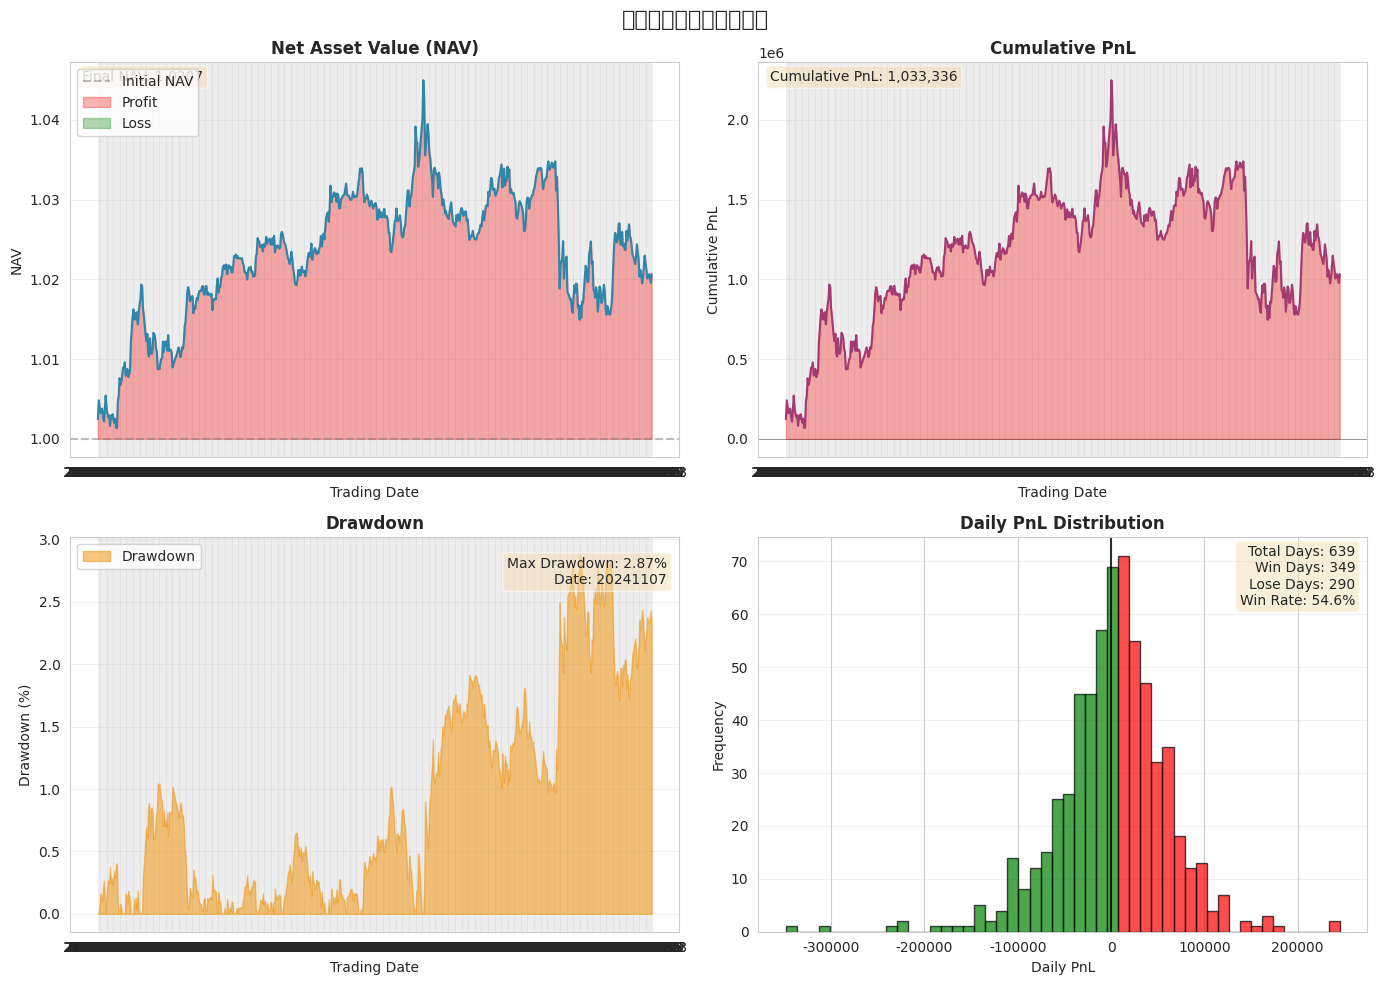

In [40]:
# 绘制绩效图表
fig, axes = backtester2.plot_performance(title='自定义信号回测绩效分析')
plt.show()